# Data Validation

## Overview

Data validation catches problems at ingestion — before they propagate silently into model training, dashboards, or reports. A single undetected data quality issue can corrupt an entire analysis.

**Types of data quality problems:**

| Problem | Example | Detection |
|---|---|---|
| Schema violations | Wrong dtype, unexpected column | Schema check |
| Range violations | Negative nitrate, richness > 200 | Bound checks |
| Distribution shift | New month's data looks different | Statistical tests |
| Duplicates | Same site sampled twice | Deduplication |
| Referential integrity | Site ID not in site registry | Join checks |
| Outliers | Sensor malfunction spike | Z-score, IQR |

**Tools:** `pandas` for manual checks, `pandera` for schema validation, `great_expectations` for production pipelines.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
n = 300
# Simulate a "raw" monitoring dataset with common data quality issues
df_raw = pd.DataFrame({
    'site_id':    [f'SITE_{i:03d}' for i in range(1, n+1)],
    'date':       pd.date_range('2022-01-01', periods=n, freq='D'),
    'elevation':  rng.uniform(50, 400, n),
    'nitrate':    rng.gamma(2, 2, n),
    'phosphorus': rng.gamma(1.5, 1.5, n),
    'richness':   rng.integers(5, 35, n).astype(float),
    'catchment':  rng.choice(['North','South','East','West'], n),
})
# Inject data quality problems
df_raw.loc[5, 'nitrate'] = -3.2           # impossible: negative
df_raw.loc[12, 'richness'] = 450.0        # implausible: too high
df_raw.loc[20, 'elevation'] = np.nan      # missing
df_raw.loc[[30,31], 'site_id'] = 'SITE_030'  # duplicate
df_raw.loc[50, 'catchment'] = 'Northwest' # not in allowed set
df_raw.loc[60, 'nitrate'] = 85.0          # outlier (sensor malfunction)
df_raw.loc[70, 'phosphorus'] = 'trace'    # wrong dtype
print(f"Shape: {df_raw.shape}")
print(df_raw.dtypes)

Shape: (300, 7)
site_id               object
date          datetime64[ns]
elevation            float64
nitrate              float64
phosphorus            object
richness             float64
catchment             object
dtype: object


C:\Users\saman\AppData\Local\Temp\ipykernel_21048\3132033730.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'trace' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_raw.loc[70, 'phosphorus'] = 'trace'    # wrong dtype


---
## Manual Validation Checks

In [2]:
issues = []

# 1. Dtype check
expected_dtypes = {'elevation':'float64','nitrate':'object',  # injected string
                   'phosphorus':'object','richness':'float64'}
for col in ['nitrate','phosphorus']:
    try:
        df_raw[col].astype(float)
    except (ValueError, TypeError):
        issues.append(f"DTYPE: {col} cannot be cast to float")

# 2. Range checks
df_numeric = df_raw.copy()
df_numeric['nitrate']    = pd.to_numeric(df_numeric['nitrate'],    errors='coerce')
df_numeric['phosphorus'] = pd.to_numeric(df_numeric['phosphorus'], errors='coerce')
range_rules = {
    'elevation':  (0,   600),
    'nitrate':    (0,   50),
    'phosphorus': (0,   20),
    'richness':   (0,   100),
}
for col, (lo, hi) in range_rules.items():
    n_below = (df_numeric[col] < lo).sum()
    n_above = (df_numeric[col] > hi).sum()
    if n_below: issues.append(f"RANGE: {col} has {n_below} values below {lo}")
    if n_above: issues.append(f"RANGE: {col} has {n_above} values above {hi}")

# 3. Allowed categories
allowed_catchments = {'North','South','East','West'}
bad_cats = set(df_raw['catchment'].unique()) - allowed_catchments
if bad_cats: issues.append(f"CATEGORY: catchment has unexpected values {bad_cats}")

# 4. Duplicates
n_dupes = df_raw['site_id'].duplicated().sum()
if n_dupes: issues.append(f"DUPLICATE: {n_dupes} duplicate site_id values")

# 5. Nulls
null_counts = df_raw.isnull().sum()
for col, cnt in null_counts[null_counts>0].items():
    issues.append(f"NULL: {col} has {cnt} missing values")

print(f"Found {len(issues)} data quality issues:")
for issue in issues:
    print(f"  [{issue.split(':')[0]}] {issue}")

Found 7 data quality issues:
  [DTYPE] DTYPE: phosphorus cannot be cast to float
  [RANGE] RANGE: nitrate has 1 values below 0
  [RANGE] RANGE: nitrate has 1 values above 50
  [RANGE] RANGE: richness has 1 values above 100
  [CATEGORY] CATEGORY: catchment has unexpected values {'Northwest'}
  [DUPLICATE] DUPLICATE: 2 duplicate site_id values
  [NULL] NULL: elevation has 1 missing values


---
## Distribution Monitoring

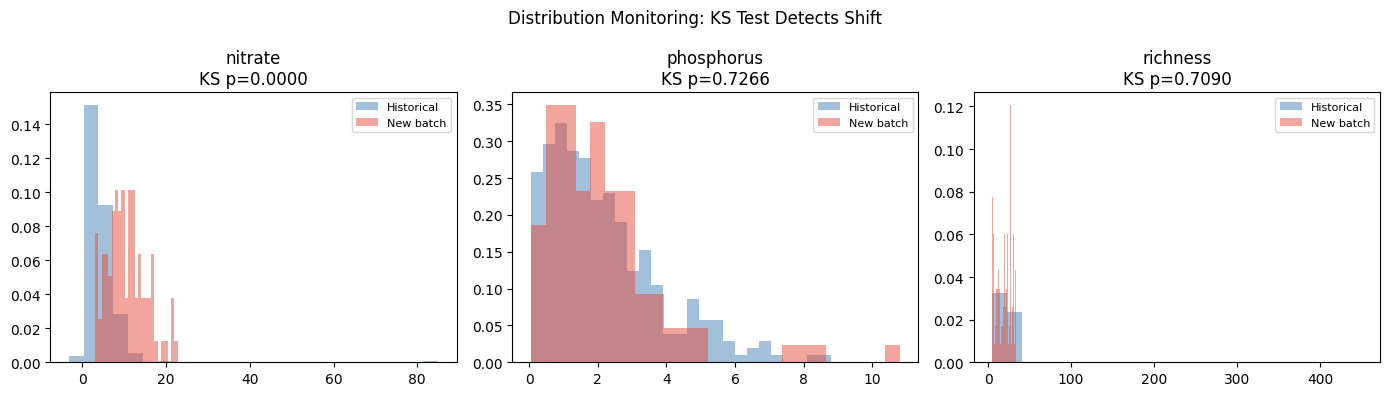

In [3]:
# Compare current batch statistics to historical baseline
# Simulate a "new" batch that has distribution shift in nitrate
df_hist = df_numeric.copy()
df_new = pd.DataFrame({
    'nitrate':    rng.gamma(4, 3, 100),   # shifted distribution
    'phosphorus': rng.gamma(1.5, 1.5, 100),
    'richness':   rng.integers(5, 35, 100).astype(float),
})
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ['nitrate','phosphorus','richness']):
    hist_vals = pd.to_numeric(df_hist[col], errors='coerce').dropna()
    new_vals  = df_new[col].dropna()
    ax.hist(hist_vals, bins=25, alpha=0.5, density=True,
            color='steelblue', label='Historical')
    ax.hist(new_vals,  bins=25, alpha=0.5, density=True,
            color='#e74c3c', label='New batch')
    ks_stat, ks_p = stats.ks_2samp(hist_vals, new_vals)
    ax.set_title(f'{col}\nKS p={ks_p:.4f}')
    ax.legend(fontsize=8)
plt.suptitle('Distribution Monitoring: KS Test Detects Shift')
plt.tight_layout(); plt.show()

---
## Pandera Schema Validation

In [6]:
try:
    import pandera.pandas as pa  # Updated import as per deprecation warning
    from pandera import Column, DataFrameSchema, Check

    schema = DataFrameSchema({
        'site_id':    Column(str, nullable=False, unique=True),
        'elevation':  Column(float, Check.between(0, 600), nullable=False),
        'nitrate':    Column(float, Check.greater_than_or_equal_to(0), nullable=True),
        'phosphorus': Column(float, Check.between(0, 20), nullable=True),
        'richness':   Column(float, Check.between(0, 150), nullable=False),
        'catchment':  Column(str,   Check.isin(['North','South','East','West'])),
    })

    # Validate a clean version of the data
    df_clean = df_numeric.copy()
    df_clean['nitrate']    = pd.to_numeric(df_clean['nitrate'],    errors='coerce')
    df_clean['phosphorus'] = pd.to_numeric(df_clean['phosphorus'], errors='coerce')

    # Fix injected problems for demo
    df_clean.loc[df_clean['nitrate']  < 0,   'nitrate']  = np.nan
    df_clean.loc[df_clean['richness'] > 150, 'richness'] = np.nan
    df_clean = df_clean[df_clean['catchment'].isin(['North','South','East','West'])]
    df_clean = df_clean.drop_duplicates('site_id')

    # Address missing values for not_nullable columns
    df_clean = df_clean.assign(
        elevation=df_clean['elevation'].fillna(df_clean['elevation'].mean()),
        richness=df_clean['richness'].fillna(df_clean['richness'].median())
    )

    try:
        validated = schema.validate(df_clean, lazy=True)
        print(f"Schema validation passed: {len(validated)} rows")
    except pa.errors.SchemaErrors as e:
        print("Schema errors found:")
        print(e.failure_cases)
except ImportError:
    print("pip install pandera")
    print("pandera schema validation example:")
    print("  schema = DataFrameSchema({'col': Column(float, Check.between(0,100))})")
    print("  schema.validate(df)  # raises SchemaErrors if validation fails")

Schema validation passed: 297 rows


In [5]:
# Automated validation report
def validate_dataframe(df, rules):
    report = []
    for check_name, check_fn in rules.items():
        try:
            result = check_fn(df)
            status = 'PASS' if result['passed'] else 'FAIL'
            report.append({'check': check_name, 'status': status,
                            'detail': result['detail']})
        except Exception as e:
            report.append({'check': check_name, 'status': 'ERROR',
                            'detail': str(e)})
    return pd.DataFrame(report)

df_v = df_numeric.copy()
df_v['nitrate']    = pd.to_numeric(df_v['nitrate'],    errors='coerce')
df_v['phosphorus'] = pd.to_numeric(df_v['phosphorus'], errors='coerce')

rules = {
    'no_negative_nitrate':  lambda d: {'passed': (d['nitrate'].dropna()>=0).all(),
                                        'detail': f"{(d['nitrate']<0).sum()} negative values"},
    'richness_in_range':    lambda d: {'passed': (d['richness'].between(0,150)).all(),
                                        'detail': f"{(~d['richness'].between(0,150)).sum()} out of range"},
    'no_duplicate_sites':   lambda d: {'passed': not d['site_id'].duplicated().any(),
                                        'detail': f"{d['site_id'].duplicated().sum()} duplicates"},
    'valid_catchments':     lambda d: {'passed': d['catchment'].isin(
                                        ['North','South','East','West']).all(),
                                        'detail': f"{(~d['catchment'].isin(['North','South','East','West'])).sum()} invalid"},
    'nitrate_missing_rate': lambda d: {'passed': d['nitrate'].isnull().mean() < 0.15,
                                        'detail': f"{d['nitrate'].isnull().mean():.1%} missing"},
}
report = validate_dataframe(df_v, rules)
print(report.to_string(index=False))

               check status            detail
 no_negative_nitrate   FAIL 1 negative values
   richness_in_range   FAIL    1 out of range
  no_duplicate_sites   FAIL      2 duplicates
    valid_catchments   FAIL         1 invalid
nitrate_missing_rate   PASS      0.0% missing


---

## Common Pitfalls

**1. Validating data only at the start of a project, not at each ingestion**  
Data quality problems most often appear in new batches — sensor recalibration, format changes, upstream database updates. Validation must run automatically on every data ingestion, not just during initial exploration.

**2. Treating a passing validation as a guarantee of correctness**  
Validation checks what you anticipated could go wrong. A passing schema check does not mean the data is correct — it means it satisfies the defined rules. Domain knowledge may reveal plausible-looking but scientifically wrong values (e.g. nitrate of 48 mg/L is technically in range but would be unusual).

**3. Silently dropping rows that fail validation without logging**  
Any row removed due to a validation failure should be logged with the reason, the row index, and the offending value. Silent dropping makes it impossible to audit data quality over time or detect systematic upstream problems.

**4. Using validation rules derived from the same dataset they are validating**  
If you set range bounds based on the min/max of the current dataset, every value will pass by construction. Range rules should come from domain knowledge (physical limits, instrument ranges, regulatory thresholds) or from a stable historical reference dataset.

**5. Not monitoring for distribution shift between training and inference data**  
A model trained on historical data may receive very different feature distributions at inference time. Range validation catches extreme values but not subtle distributional shifts. Use KS tests or population stability index (PSI) to monitor whether the distribution of each feature has drifted from the training distribution.

---
*python_methods_library - Samantha McGarrigle*